


**Import Libraries**


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

**Load Dataset**

In [4]:
data = pd.read_csv("/content/IMDB_Dataset[1].csv")

In [5]:
data.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


**Data preprocessing**

In [6]:
data.replace({"sentiment": {"positive": 1, "negative": 0}}, inplace=True)

/tmp/ipykernel_1758/2568826810.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data.replace({"sentiment": {"positive": 1, "negative": 0}}, inplace=True)


In [7]:
data.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [10]:
data.drop_duplicates(inplace = True)

In [11]:
data['review'] = data['review'].str.lower()

In [12]:
import re
def remove_html_tags(text):
    pattern = r'[^a-zA-Z0-9\s]'
    text = re.sub(pattern,'',text)
    return text
data['review'] = data['review'].apply(remove_html_tags)

In [13]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
# Intilize Stopwords
stop_words = set(stopwords.words('english'))

# Apply Stopwords
data['review'] = data['review'].apply(lambda x : ' '.join([word for word in x.split() if word not in (stop_words)]))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [15]:
data['review'] = data['review'].str.replace(r'http\S+|www.\S+', '', case=False)

**Split Data**

In [16]:
train_data, test_data = train_test_split(data, test_size=0.2, random_state=42)

**Tokenize and Pad Sequences**

In [17]:
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(train_data["review"])
X_train = pad_sequences(tokenizer.texts_to_sequences(train_data["review"]), maxlen=200)
X_test = pad_sequences(tokenizer.texts_to_sequences(test_data["review"]), maxlen=200)

In [18]:
Y_train = train_data["sentiment"]
Y_test = test_data["sentiment"]

**Build and Train LSTM Model**

In [19]:
model = Sequential()
model.add(Embedding(input_dim=5000, output_dim=128 ,  input_shape=(200,)))
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation="sigmoid"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 771,713 (2.94 MB)

 Trainable params: 771,713 (2.94 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [23]:
history = model.fit(X_train, Y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 199s 401ms/step - accuracy: 0.9404 - loss: 0.1577 - val_accuracy: 0.8703 - val_loss: 0.3946
Epoch 2/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 193s 390ms/step - accuracy: 0.9479 - loss: 0.1395 - val_accuracy: 0.8629 - val_loss: 0.3976
Epoch 3/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 191s 386ms/step - accuracy: 0.9554 - loss: 0.1207 - val_accuracy: 0.8600 - val_loss: 0.4396
Epoch 4/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 196s 396ms/step - accuracy: 0.9598 - loss: 0.1121 - val_accuracy: 0.8610 - val_loss: 0.4235
Epoch 5/5
496/496 ━━━━━━━━━━━━━━━━━━━━ 236s 475ms/step - accuracy: 0.9660 - loss: 0.0942 - val_accuracy: 0.8582 - val_loss: 0.4517


**Evaluate Model**

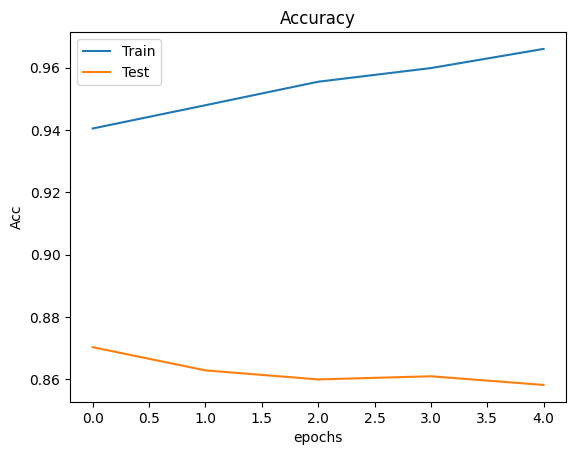

In [24]:
plt.figure()
plt.plot(history.history["accuracy"], label = "Train")
plt.plot(history.history["val_accuracy"], label = "Test")
plt.title("Accuracy")
plt.ylabel("Acc")
plt.xlabel("epochs")
plt.legend()
plt.show()

In [25]:
loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

310/310 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.8595 - loss: 0.4574
Test Loss: 0.4574113190174103
Test Accuracy: 0.8595341444015503


**Logistic Regression**

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [27]:
A = data['review']
B = data['sentiment']

In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(A,B, test_size=0.2, random_state=42)

In [29]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')  # Limit to 5000 features for simplicity
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [30]:
log_reg = LogisticRegression(max_iter=500)  # Increase max_iter if convergence issues occur
log_reg.fit(X_train_tfidf, Y_train)

LogisticRegression(max_iter=500)

In [32]:
y_pred = log_reg.predict(X_test_tfidf)

In [33]:
accuracy = accuracy_score(Y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.88


**Save Models**

In [34]:
import pickle

In [35]:
pickle.dump(tokenizer ,open('tokenizer.pkl' , 'wb'))

In [37]:
pickle.dump(model ,open('model.pkl' , 'wb'))